# Feature Correlations Notebook
This notebook is to check the correlations of the model features as well as to check the cross-correlations of the feautures across datasets

### Load the libraries needed

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the datasets

In [2]:
industry_df = pd.read_csv("data/potential_model_features/percents_sa/industry_level_totals_exp.csv")
national_df = pd.read_csv("data/potential_model_features/percents_sa/national_level_totals_exp.csv")
regional_df = pd.read_csv("data/potential_model_features/percents_sa/regional_level_totals_exp.csv")
state_df = pd.read_csv("data/potential_model_features/percents_sa/state_level_totals_exp.csv")

## Plot the correlation matrices of the datasets against themselves

In [3]:
import re

def shorten_names(df):
    df = df.copy()  # Avoid modifying original DataFrame
    df.columns = [re.split(r'\s*-\s*', col)[0] for col in df.columns]
    return df

### Industry Correlations

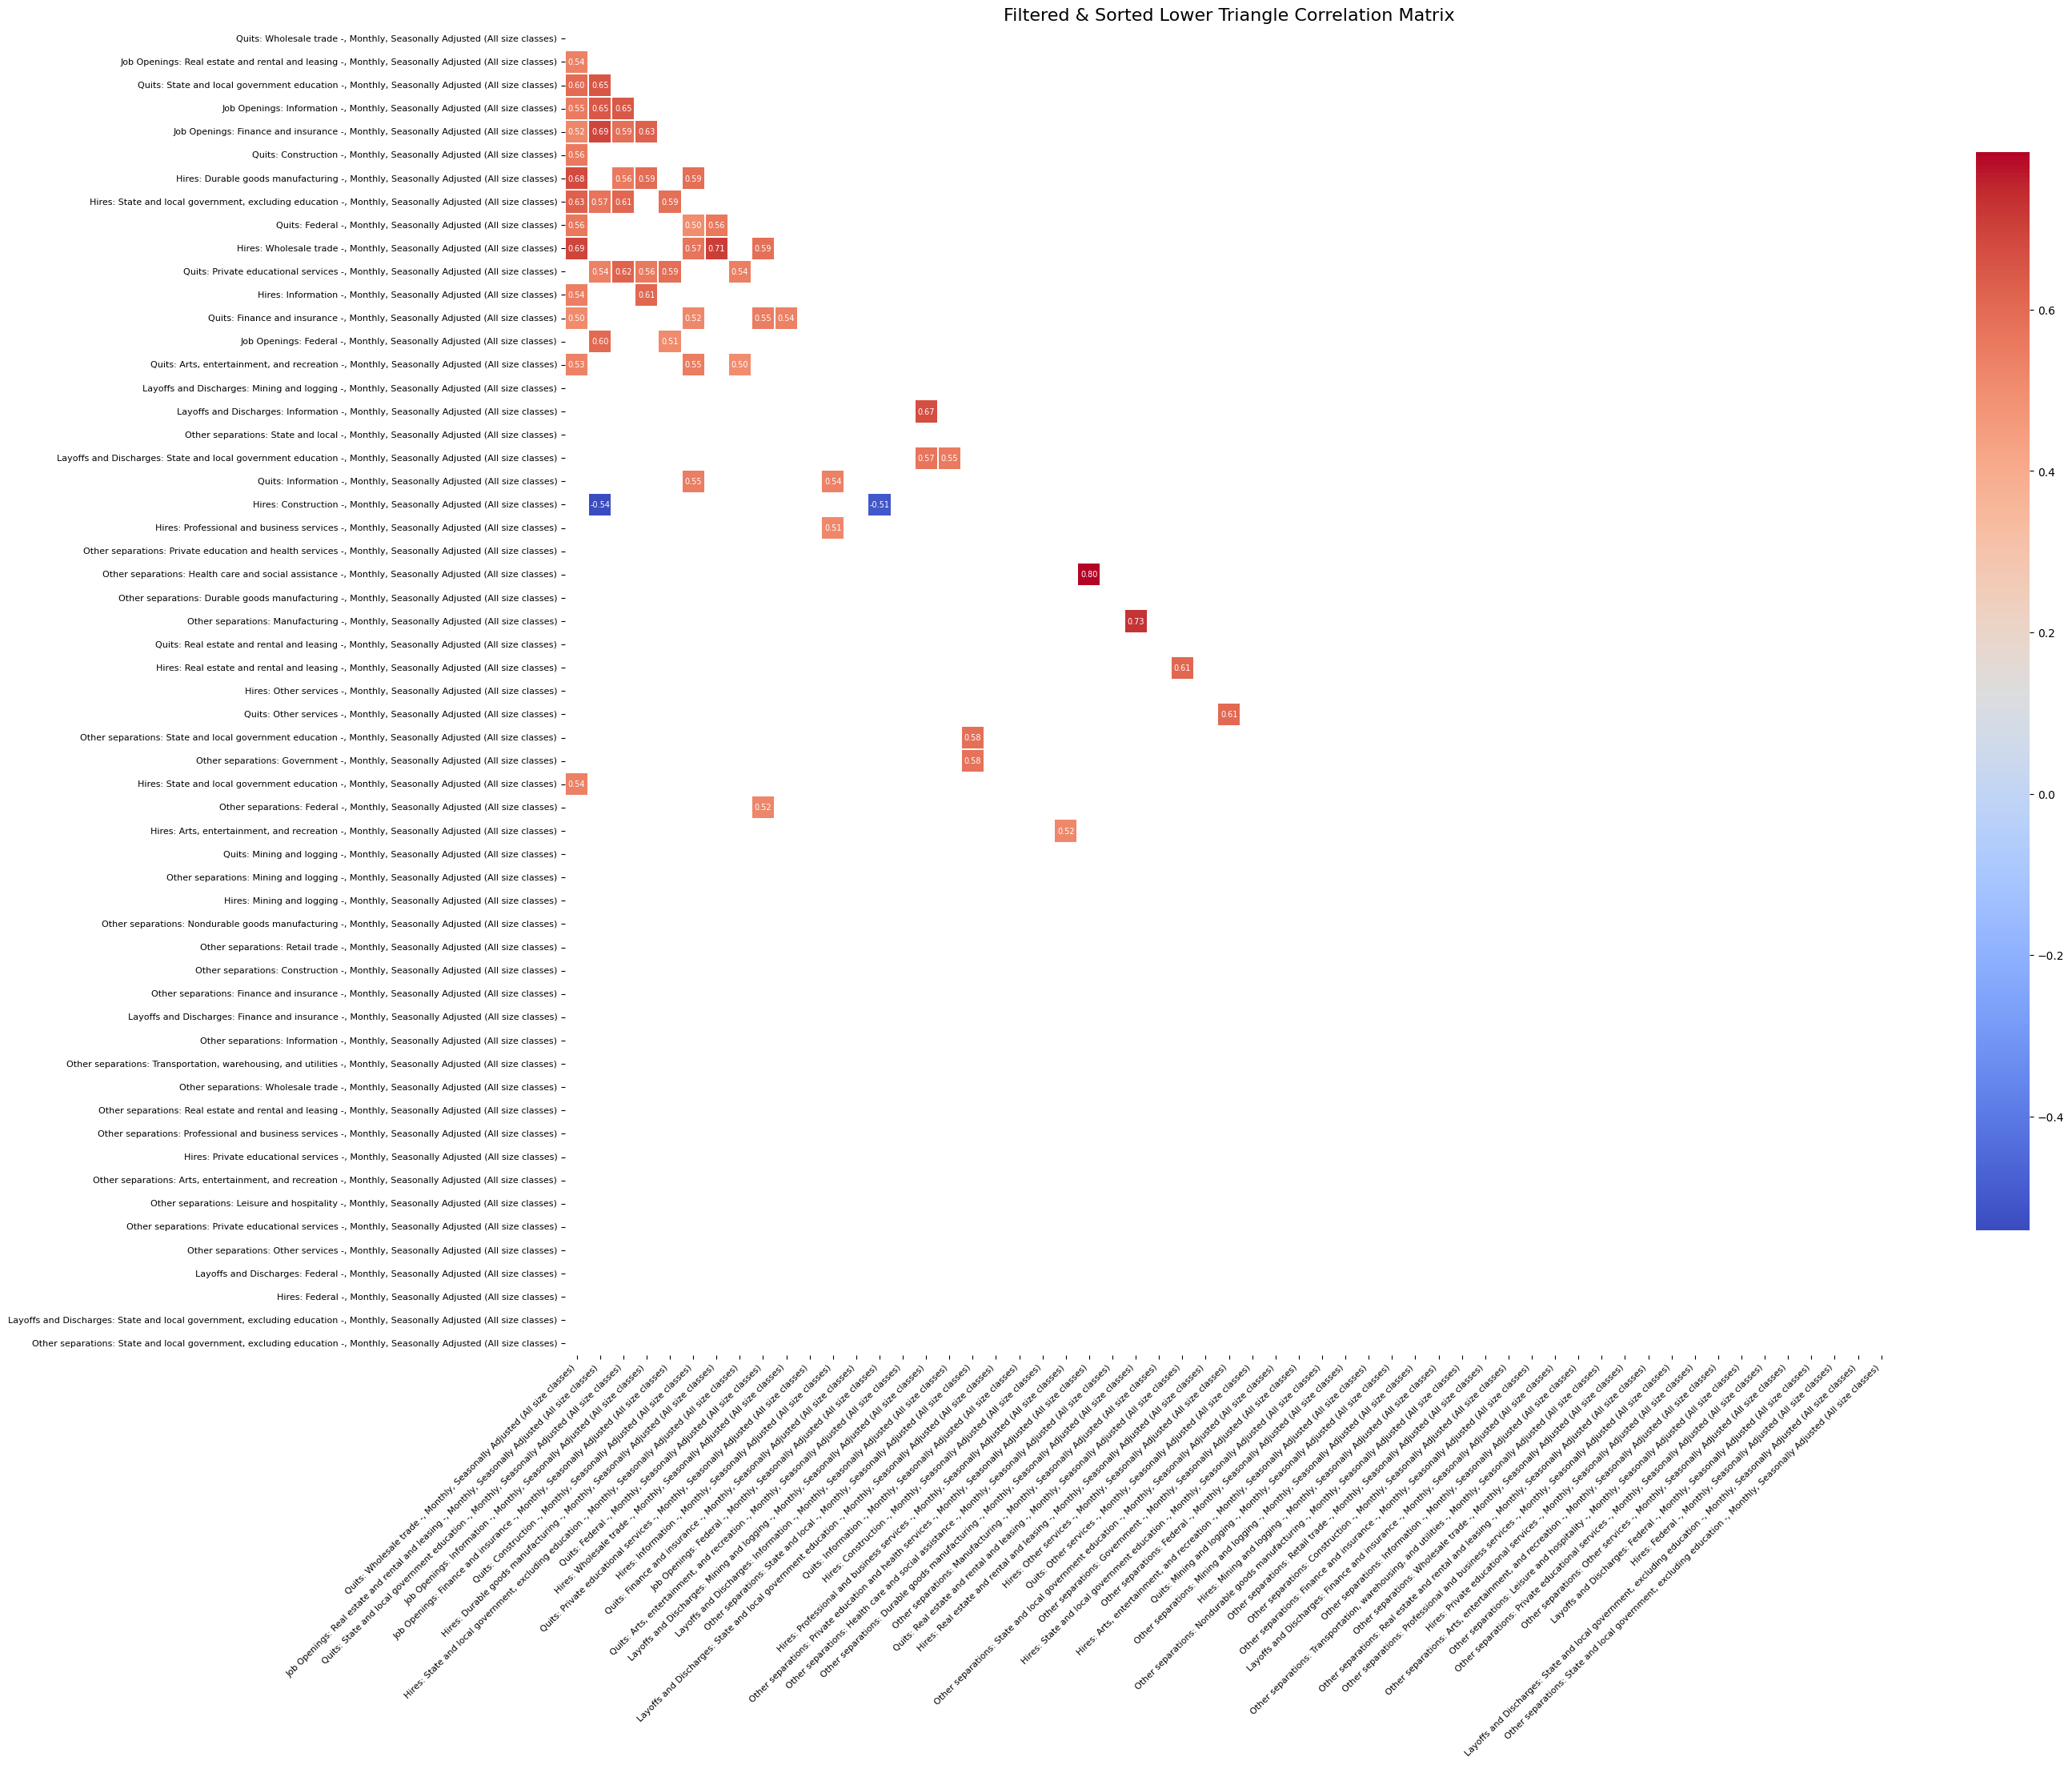

In [4]:
# Step 1: Compute correlation matrix
corr = industry_df.corr()

# Step 2: Filter weak correlations (absolute value < 0.3)
filtered_corr = corr.where(np.abs(corr) >= 0.5)

# Step 3: Sort features by total correlation strength
strength = filtered_corr.abs().sum().sort_values(ascending=False)
sorted_corr = filtered_corr.loc[strength.index, strength.index]

# Step 4: Mask upper triangle
mask = np.triu(np.ones_like(sorted_corr, dtype=bool))

# Step 5: Plot heatmap with readability enhancements
plt.figure(figsize=(28, 24))
sns.heatmap(
    sorted_corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 7}
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Filtered & Sorted Lower Triangle Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### Grab all the important correlations and put them into a different industry_df

In [5]:
# Step 1: Compute absolute correlation matrix
corr_matrix = industry_df.corr().abs()

# Step 2: Set threshold for strong correlation
threshold = 0.5

# Step 3: Identify features with at least one strong correlation (excluding self-correlation)
strong_corr_mask = (corr_matrix > threshold) & (np.eye(len(corr_matrix)) == 0)
features_to_keep = strong_corr_mask.any(axis=1)

# Step 4: Filter original DataFrame to keep only those features
industry_df_strong = industry_df.loc[:, features_to_keep]

# Optional: print resulting feature names
print("Retained features with strong correlations:")
print(industry_df_strong.columns.tolist())
print(len(industry_df_strong.columns))

industry_df_strong.head()

Retained features with strong correlations:
['Layoffs and Discharges: Mining and logging -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Construction -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Construction -, Monthly, Seasonally Adjusted (All size classes)', 'Other separations: Manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Other separations: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)', 'Hires: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Job Openings: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Layoffs and Discharges: Information -, Monthly, Seasonally Adjusted (All size classes)', 'Quits: Information -, Monthly, Seas

,"Layoffs and Discharges: Mining and logging -, Monthly, Seasonally Adjusted (All size classes)","Hires: Construction -, Monthly, Seasonally Adjusted (All size classes)","Quits: Construction -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Hires: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Durable goods manufacturing -, Monthly, Seasonally Adjusted (All size classes)","Hires: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)","Quits: Wholesale trade -, Monthly, Seasonally Adjusted (All size classes)","Hires: Information -, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Information -, Monthly, Seasonally Adjusted (All size classes)",...,"Other separations: Government -, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Federal -, Monthly, Seasonally Adjusted (All size classes)","Other separations: Federal -, Monthly, Seasonally Adjusted (All size classes)","Quits: Federal -, Monthly, Seasonally Adjusted (All size classes)","Other separations: State and local -, Monthly, Seasonally Adjusted (All size classes)","Hires: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Other separations: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Quits: State and local government education -, Monthly, Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education -, Monthly, Seasonally Adjusted (All size classes)"
0,2.0,6.1,1.6,0.3,2.5,0.3,2.7,1.1,3.0,4.2,...,0.2,2.4,0.3,0.6,0.2,1.6,0.5,0.2,0.6,1.8
1,1.6,7.2,2.4,0.2,2.6,0.3,2.5,1.7,4.6,4.3,...,0.2,2.4,0.3,0.7,0.2,1.5,0.4,0.2,0.7,1.8
2,0.9,7.1,2.6,0.2,2.5,0.2,2.8,1.6,3.6,3.8,...,0.2,2.2,0.3,0.6,0.2,1.8,0.5,0.2,0.6,1.9
3,1.4,8.4,2.9,0.3,2.4,0.3,2.5,1.6,3.0,3.4,...,0.2,2.1,0.2,0.7,0.2,1.6,0.4,0.2,0.7,1.8
4,1.3,6.7,2.9,0.3,2.3,0.3,2.7,1.5,3.4,4.4,...,0.3,2.3,0.3,0.6,0.2,1.6,0.3,0.2,0.5,1.7


### Plot the correlation matrix of the strong dataframe

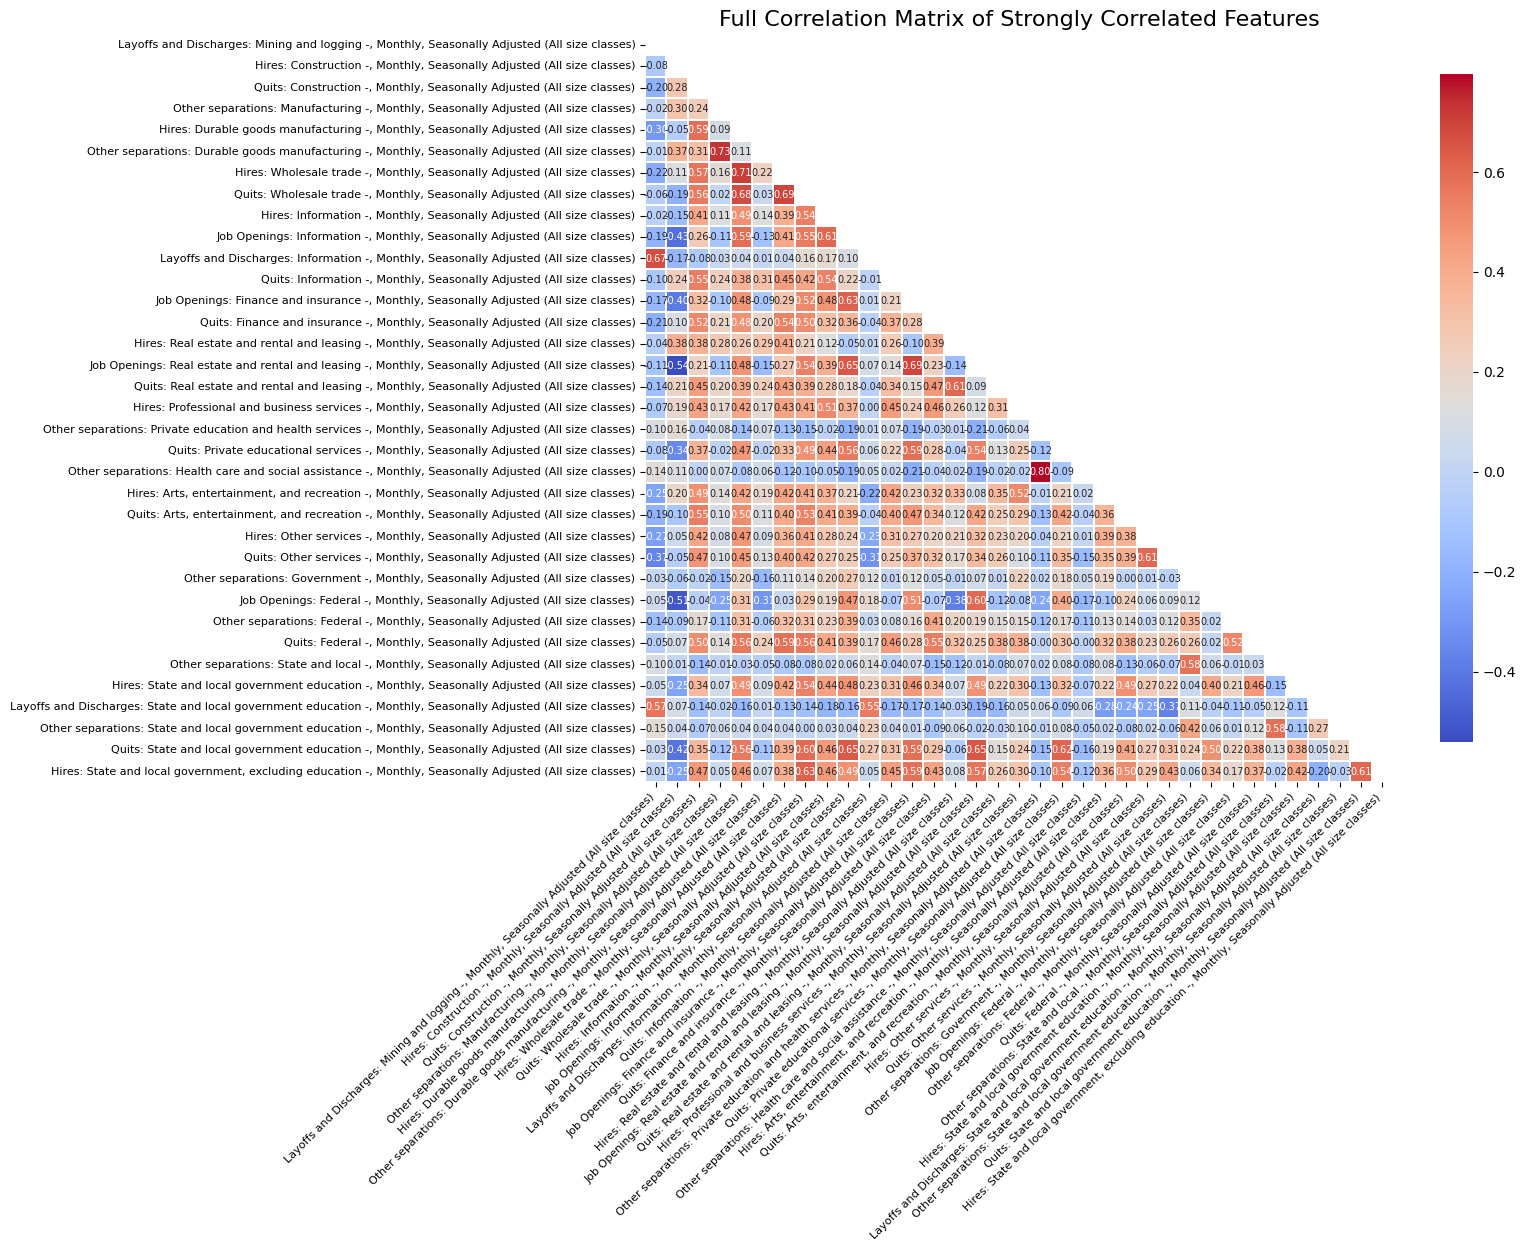

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Compute full correlation matrix
corr_matrix = industry_df_strong.corr()

# Step 4: Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 2: Set up the plot
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 7}
)

# Step 3: Improve label readability
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Full Correlation Matrix of Strongly Correlated Features', fontsize=16)
plt.tight_layout()
plt.show()

### Plot the cross-correlation matrices of these features with all the other dataframes we have

In [16]:
# Step 1: Compute cross-correlation matrix manually
def compute_cc_top10(m1, m2, c1, c2):
    cross_corr_matrix = pd.DataFrame(
        np.corrcoef(m1.T, m2.T)[:m1.shape[1], m1.shape[1]:],
        index=m1.columns,
        columns=m2.columns
    )
    # Flatten the matrix
    flat_corrs = cross_corr_matrix.stack().reset_index()
    flat_corrs.columns = [c1, c2, 'Correlation']

    # Sort by absolute correlation
    flat_corrs['AbsCorr'] = flat_corrs['Correlation'].abs()
    sorted_corrs = flat_corrs.sort_values(by='AbsCorr', ascending=False)

    return sorted_corrs.head(10)


In [17]:
i_state = compute_cc_top10(industry_df_strong, state_df, 'Industry', 'StateFeatures')
i_region = compute_cc_top10(industry_df_strong, regional_df, 'Industry', 'RegionFeatures')
i_nation = compute_cc_top10(industry_df_strong, national_df, 'Industry', 'NationFeatures')

In [18]:
i_state

,Industry,StateFeatures,Correlation,AbsCorr
637,"Layoffs and Discharges: Information -, Monthly...",Layoffs and Discharges: Total nonfarm in South...,0.786802,0.786802
632,"Layoffs and Discharges: Information -, Monthly...","Total Separations: Total nonfarm in Oregon -, ...",0.768967,0.768967
449,"Quits: Wholesale trade -, Monthly, Seasonally ...","Quits: Total nonfarm in New York -, Monthly, S...",0.717067,0.717067
443,"Quits: Wholesale trade -, Monthly, Seasonally ...","Quits: Total nonfarm in Nevada -, Monthly, Sea...",0.712275,0.712275
467,"Quits: Wholesale trade -, Monthly, Seasonally ...","Quits: Total nonfarm in Virginia -, Monthly, S...",0.705703,0.705703
446,"Quits: Wholesale trade -, Monthly, Seasonally ...","Quits: Total nonfarm in New Jersey -, Monthly,...",0.692645,0.692645
2046,"Hires: State and local government, excluding e...","Quits: Total nonfarm in Ohio -, Monthly, Seaso...",0.685316,0.685316
246,"Hires: Durable goods manufacturing -, Monthly,...","Hires: Total nonfarm in Illinois -, Monthly, S...",0.684274,0.684274
429,"Quits: Wholesale trade -, Monthly, Seasonally ...","Quits: Total nonfarm in Louisiana -, Monthly, ...",0.683619,0.683619
1987,"Quits: State and local government education -,...","Quits: Total nonfarm in Ohio -, Monthly, Seaso...",0.683521,0.683521


In [19]:
i_region

,Industry,RegionFeatures,Correlation,AbsCorr
95,"Layoffs and Discharges: Information -, Monthly...",Layoffs and Discharges: Total nonfarm in South...,0.901856,0.901856
138,Job Openings: Real estate and rental and leasi...,Job Openings: Total nonfarm in Northeast regio...,0.812548,0.812548
84,"Job Openings: Information -, Monthly, Seasonal...",Job Openings: Total nonfarm in Northeast regio...,0.803408,0.803408
111,"Job Openings: Finance and insurance -, Monthly...",Job Openings: Total nonfarm in Northeast regio...,0.748383,0.748383
300,"Quits: State and local government education -,...",Job Openings: Total nonfarm in Northeast regio...,0.742645,0.742645
63,"Quits: Wholesale trade -, Monthly, Seasonally ...","Hires: Total nonfarm in Midwest region -, Mont...",0.718283,0.718283
5,"Layoffs and Discharges: Mining and logging -, ...",Layoffs and Discharges: Total nonfarm in South...,0.716042,0.716042
36,"Hires: Durable goods manufacturing -, Monthly,...","Hires: Total nonfarm in Midwest region -, Mont...",0.705409,0.705409
237,"Job Openings: Federal -, Monthly, Seasonally A...",Job Openings: Total nonfarm in Northeast regio...,0.702654,0.702654
25,"Quits: Construction -, Monthly, Seasonally Adj...","Hires: Total nonfarm in West region -, Monthly...",0.696934,0.696934


In [20]:
i_nation

,Industry,NationFeatures,Correlation,AbsCorr
14,"Layoffs and Discharges: Mining and logging -, ...","Total Separations: Mining and logging -, Month...",0.812090,0.812090
239,"Layoffs and Discharges: Information -, Monthly...","Layoffs and Discharges: Total private -, Month...",0.802565,0.802565
99,"Hires: Durable goods manufacturing -, Monthly,...","Hires: Total private -, Monthly, Seasonally Ad...",0.779063,0.779063
780,"Quits: State and local government education -,...",Total Separations: State and local government ...,0.743768,0.743768
50,"Quits: Construction -, Monthly, Seasonally Adj...","Hires: Total private -, Monthly, Seasonally Ad...",0.741843,0.741843
246,"Layoffs and Discharges: Information -, Monthly...","Total Separations: Wholesale trade -, Monthly,...",0.738397,0.738397
249,"Layoffs and Discharges: Information -, Monthly...",Total Separations: Professional and business s...,0.723186,0.723186
248,"Layoffs and Discharges: Information -, Monthly...",Total Separations: Real estate and rental and ...,0.720923,0.720923
168,"Quits: Wholesale trade -, Monthly, Seasonally ...","Hires: Total private -, Monthly, Seasonally Ad...",0.703780,0.703780
316,"Quits: Finance and insurance -, Monthly, Seaso...","Total Separations: Finance and insurance -, Mo...",0.679879,0.679879
